# Algorithm 3 Sample construction from 
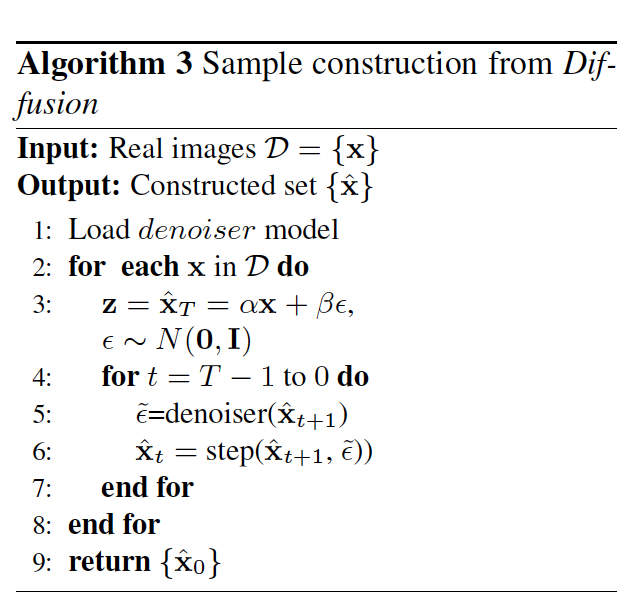

In [1]:
# PixelFlow import
import sys
!git clone https://github.com/ShoufaChen/PixelFlow
# sys.path.append('/kaggle/working/PixelFlow')

Cloning into 'PixelFlow'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 36 (delta 10), reused 13 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 48.84 KiB | 6.10 MiB/s, done.
Resolving deltas: 100% (10/10), done.


## Load imports

In [3]:
import torch
import requests
from PIL import Image
import torchvision.transforms as T
import os

In [4]:
def get_safe_device():
    """
    Safely detect device. If CUDA fails, fall back to CPU.
    """
    if torch.cuda.is_available():
        try:
            # Test CUDA with a simple operation
            test = torch.randn(1, device='cuda')
            print("✓ CUDA available and working")
            return torch.device("cuda")
        except RuntimeError as e:
            print(f"✗ CUDA error detected: {e}")
            print("  Falling back to CPU for inference")
            return torch.device("cpu")
    else:
        print("⚠ CUDA not available, using CPU")
        return torch.device("cpu")
 
DEVICE = get_safe_device()
print(f"Using device: {DEVICE}")

✓ CUDA available and working
Using device: cuda


In [5]:
from PixelFlow.pixelflow.model import PixelFlowModel

/kaggle/working/PixelFlow/pixelflow/model.py:12: UserWarning: `flash-attn` is not installed. Training mode may not work properly.
  warnings.warn("`flash-attn` is not installed. Training mode may not work properly.", UserWarning)


## Model loading

In [6]:
denoiser = PixelFlowModel(num_attention_heads=16,
                          attention_head_dim=72,
                          in_channels=3,
                          out_channels=3,
                          depth=28,
                          num_classes=1000,
                          patch_size=4
                        )
 
checkpoint = torch.load('/kaggle/input/models/adityal0/pixelflow-diffusion/pytorch/default/1/pixelflow_model.pt', map_location=DEVICE)
 
# Check if it's a state_dict or a wrapped checkpoint
if "state_dict" in checkpoint:
    message = denoiser.load_state_dict(checkpoint["state_dict"], strict=False)
else:
    message = denoiser.load_state_dict(checkpoint, strict=False)
print(f"Loaded weights with partial match: {message}")

denoiser.to(DEVICE)
denoiser.eval()

Starting Initialization...
Loaded weights with partial match: _IncompatibleKeys(missing_keys=['class_embedder.embedding_table.weight'], unexpected_keys=['transformer_blocks.0.norm2.weight', 'transformer_blocks.0.attn2.q_proj.weight', 'transformer_blocks.0.attn2.q_proj.bias', 'transformer_blocks.0.attn2.k_proj.weight', 'transformer_blocks.0.attn2.k_proj.bias', 'transformer_blocks.0.attn2.v_proj.weight', 'transformer_blocks.0.attn2.v_proj.bias', 'transformer_blocks.0.attn2.o_proj.weight', 'transformer_blocks.0.attn2.o_proj.bias', 'transformer_blocks.0.attn2.q_norm.weight', 'transformer_blocks.0.attn2.k_norm.weight', 'transformer_blocks.1.norm2.weight', 'transformer_blocks.1.attn2.q_proj.weight', 'transformer_blocks.1.attn2.q_proj.bias', 'transformer_blocks.1.attn2.k_proj.weight', 'transformer_blocks.1.attn2.k_proj.bias', 'transformer_blocks.1.attn2.v_proj.weight', 'transformer_blocks.1.attn2.v_proj.bias', 'transformer_blocks.1.attn2.o_proj.weight', 'transformer_blocks.1.attn2.o_proj.bias

PixelFlowModel(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1152, kernel_size=(4, 4), stride=(4, 4))
  )
  (time_proj): Timesteps()
  (timestep_embedder): TimestepEmbedding(
    (linear_1): Linear(in_features=256, out_features=1152, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1152, out_features=1152, bias=True)
  )
  (latent_size_embedder): TimestepEmbedding(
    (linear_1): Linear(in_features=256, out_features=1152, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1152, out_features=1152, bias=True)
  )
  (class_embedder): LabelEmbedding(
    (embedding_table): Embedding(1001, 1152)
  )
  (transformer_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (norm1): AdaLayerNorm(
        (silu): SiLU()
        (linear): Linear(in_features=1152, out_features=6912, bias=True)
        (norm): LayerNorm((1152,), eps=1e-06, elementwise_affine=False)
      )
      (attn1): Attention(
        (q_proj): Linear(in_features=1152, out_features=1152,

## Assigning Parameters

In [7]:
# hyperparameters from the paper (Algorithm 3)
T_STEPS = 25     # no. of denoising iterations
STRENGTH = 0.2      # noise strength

RES = 256
PATCH_SIZE = 4
HEAD_DIM = denoiser.attention_head_dim # 72
SEQ_LEN = (RES // PATCH_SIZE) ** 2     # 4096

# Create the dummy embedding once and keep it on the GPU
DUMMY_POS = torch.zeros((SEQ_LEN, HEAD_DIM, 2), device=DEVICE).half()
CLASS_LABELS = torch.zeros((1,), device=DEVICE, dtype=torch.long)
CURR_LATENT_SIZE = torch.tensor([float(RES)], device=DEVICE).half()

## Diffusion Algorithm 

In [8]:
@torch.no_grad()
def algorithm_3_diffusion_v4(image_path, denoiser):
    # 1. LOAD IMAGE (SEC 5.1: USE CROP, NOT RESIZE)
    raw_img = Image.open(image_path).convert("RGB")

    RES = 256
    
    # Check if image is large enough, otherwise this sample should be skipped
    # based on "whenever the resolution allows" in Sec 5.1
    center_crop = T.CenterCrop(RES) 
    cropped_img = center_crop(raw_img)
    
    x_real = T.ToTensor()(cropped_img).unsqueeze(0).to(DEVICE).half()
    x_real = x_real * 2 - 1  # Map to [-1, 1]

    # 2. ADD NOISE (ALG 3, LINE 3)
    # z = alpha * x + beta * epsilon. For Flow Matching: x_t = (1-t)x + t*eps
    epsilon = torch.randn_like(x_real)
    # Using STRENGTH as our starting 't'
    x_t = (1 - STRENGTH) * x_real + STRENGTH * epsilon
    
    # 3. DENOISING LOOP (ALG 3, LINES 4-7)
    dt = STRENGTH / T_STEPS

    for i in range(T_STEPS):
        # Calculate current t dropping from STRENGTH to 0
        t_val = STRENGTH - (i * dt)
        curr_t = torch.tensor([t_val], device=DEVICE).half()

        # ALG 3, LINE 5: Get the "Final Touch" from the denoiser
        v_pred = denoiser(
            hidden_states=x_t,
            encoder_hidden_states=None,
            class_labels=CLASS_LABELS,
            timestep=curr_t * 1000, # Most models scale t by 1000
            latent_size=CURR_LATENT_SIZE,
            pos_embed=DUMMY_POS
        )
        
        # ALG 3, LINE 6: Update step
        # In Flow Matching, the ODE is dx/dt = v. 
        # To go from noise (t=1) to data (t=0), we move in direction -v.
        x_t = x_t - v_pred * dt 
    
    # 4. FINAL OUTPUT
    x_hat = (x_t + 1) / 2
    x_hat = x_hat.clamp(0, 1).cpu().float().squeeze(0)

    return T.ToPILImage()(x_hat)

In [9]:
image_1 = algorithm_3_diffusion_v4("/kaggle/input/datasets/adityal0/real-images-uncovai/ID_0000.jpg", denoiser=denoiser)

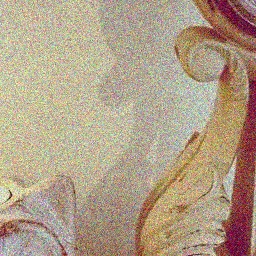

In [10]:
image_1

## Diffusion Algorithm for Batch Images

In [19]:
@torch.no_grad()
def algorithm_3_batch_v4(image_paths, denoiser):
    # 1. LOAD & PREPROCESS BATCH
    RES = 256
    transform = T.Compose([
        T.CenterCrop(RES),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Efficiently maps to [-1, 1]
    ])
    
    # Load all images in the current batch list
    imgs = [transform(Image.open(p).convert("RGB")) for p in image_paths]
    x_t_real = torch.stack(imgs).to(DEVICE)
    curr_batch_size = x_t_real.shape[0]

    # batch_pos = DUMMY_POS.unsqueeze(0).expand(curr_batch_size, -1, -1, -1)
    # batch_latent_size = CURR_LATENT_SIZE.unsqueeze(0).expand(curr_batch_size, -1)

    # 2. ADD NOISE
    epsilon = torch.randn_like(x_t_real)
    x_t = (1 - STRENGTH) * x_t_real + STRENGTH * epsilon
    
    # Constants scaled to batch size
    batch_class_labels = torch.zeros((curr_batch_size,), device=DEVICE, dtype=torch.long)
    dt = STRENGTH / T_STEPS

    
    # 3. DENOISING LOOP
    for i in range(T_STEPS):
        t_val = STRENGTH - (i * dt)
        curr_t = torch.full(
                            (curr_batch_size,),
                            t_val * 1000,
                            device=DEVICE,
                            dtype=torch.float32
                        )

        with torch.amp.autocast('cuda'):
            v_pred = denoiser(
                hidden_states=x_t,
                encoder_hidden_states=None,
                class_labels=batch_class_labels,
                timestep=curr_t, # Most models scale t by 1000
                latent_size=CURR_LATENT_SIZE,
                pos_embed=DUMMY_POS
            )
        x_t = x_t - v_pred * dt 
    
    # 4. POST-PROCESS
    x_hat = (x_t + 1) / 2
    x_hat = x_hat.clamp(0, 1).cpu().float()
    return [T.ToPILImage()(img) for img in x_hat]

## Constructed Fake Images

In [13]:
DEVICE = "cuda:0"  # force single GPU
BATCH_SIZE = 8  # or 12 if memory allows

In [10]:
import glob

# Use glob to get absolute paths for all .jpg files in that directory
input_folder = '/kaggle/input/datasets/adityal0/real-images-uncovai'
image_paths = sorted(glob.glob(f"{input_folder}/*.jpg"))[:100]

In [21]:
from tqdm.auto import tqdm
import os

output_dir = '/kaggle/working/fake_diffusion'
os.makedirs(output_dir, exist_ok=True)

pbar = tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Processing Batches")

for i in pbar:
    batch_paths = image_paths[i : i + BATCH_SIZE]
    
    results = algorithm_3_batch_v4(batch_paths, denoiser)
    
    for img, path in zip(results, batch_paths):
        filename = os.path.basename(path)
        save_path = os.path.join(output_dir, filename)
        img.save(save_path)

    pbar.set_postfix({
        "batch_size": len(batch_paths),
        "last_file": os.path.basename(batch_paths[-1])
    })

Processing Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [26]:
import shutil
import os

# Path to your output folder
output_dir = '/kaggle/working/fake_diffusion'

# Path for the zip file
zip_path = '/kaggle/working/fake_diffusion.zip'

# Create the zip archive
shutil.make_archive(zip_path.replace('.zip',''), 'zip', output_dir)

## Checking real and constructed images

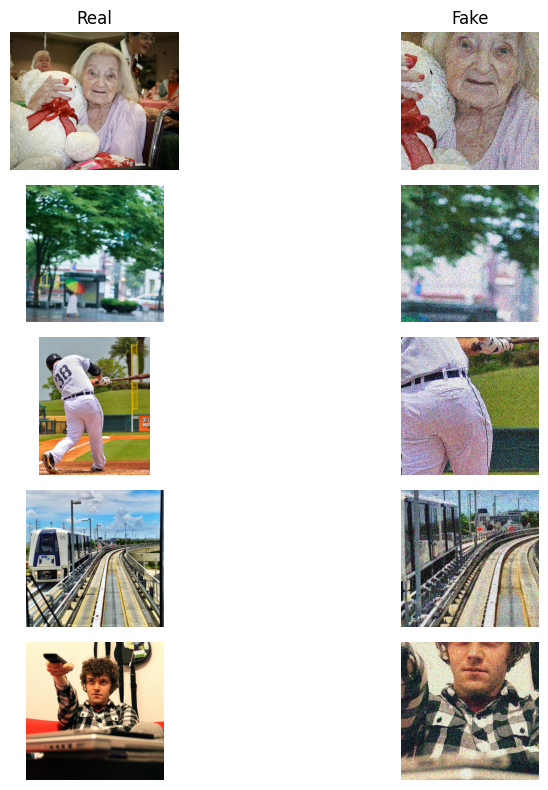

In [27]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# path
input_folder = '/kaggle/input/datasets/adityal0/real-images-uncovai'
output_folder = '/kaggle/working/fake_diffusion'

# sorted images
real_images = sorted([os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith('.jpg')])
fake_images = sorted([os.path.join(output_folder, f) for f in os.listdir(output_folder) if f.endswith('.jpg')])

# random 5 images
sample_indices = random.sample(range(min(len(real_images), len(fake_images))), 5)

plt.figure(figsize=(10, 8))

for i, idx in enumerate(sample_indices):
    # load image
    real_img = Image.open(real_images[idx]).convert("RGB")
    fake_img = Image.open(fake_images[idx]).convert("RGB")
    
    # Plot real
    plt.subplot(5, 2, 2*i + 1)
    plt.imshow(real_img)
    plt.axis('off')
    if i == 0:
        plt.title('Real')
    
    # Plot fake
    plt.subplot(5, 2, 2*i + 2)
    plt.imshow(fake_img)
    plt.axis('off')
    if i == 0:
        plt.title('Fake')

plt.tight_layout()
plt.show()